In [33]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import *
from xgboost import XGBRegressor
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings("ignore")

ModuleNotFoundError: No module named 'xgboost'

In [2]:
df = pd.read_csv("../dataset/insurance.csv")
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1338.0,39.207025,14.049960,18.0000,27.00000,39.000,51.000000,64.00000
bmi,1338.0,30.663397,6.098187,15.9600,26.29625,30.400,34.693750,53.13000
children,1338.0,1.094918,1.205493,0.0000,0.00000,1.000,2.000000,5.00000
charges,1338.0,13270.422265,12110.011237,1121.8739,4740.28715,9382.033,16639.912515,63770.42801


In [5]:
df.duplicated().sum()

np.int64(1)

In [6]:
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

Text(0.5, 1.0, 'Distribution of charges')

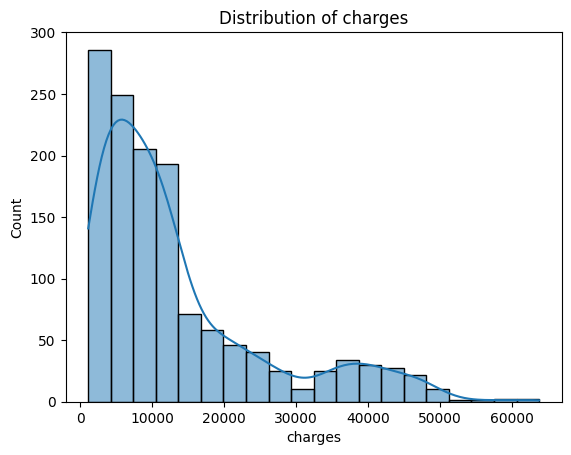

In [7]:
sns.histplot(data=df, x='charges', bins=20, kde=True)
plt.title("Distribution of charges")

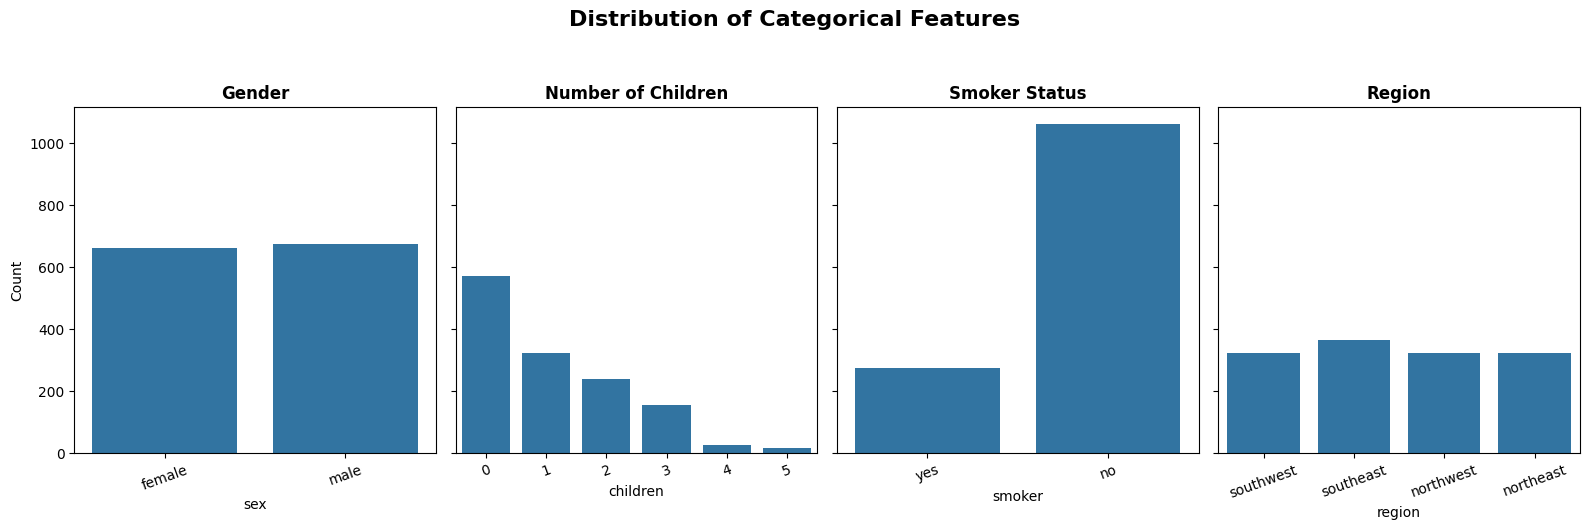

In [8]:
fig, axs = plt.subplots(
    nrows=1,
    ncols=4,
    figsize=(16, 5),
    sharey=True
)

axs = axs.ravel()

cols = ['sex', 'children', 'smoker', 'region']
titles = ['Gender', 'Number of Children', 'Smoker Status', 'Region']

for i, col in enumerate(cols):
    sns.countplot(
        data=df,
        x=col,
        ax=axs[i]
    )
    
    axs[i].set_title(titles[i], fontsize=12, fontweight='bold')
    axs[i].set_xlabel(col, fontsize=10)
    axs[i].set_ylabel('Count' if i == 0 else '')
    axs[i].tick_params(axis='x', rotation=20)

plt.suptitle(
    "Distribution of Categorical Features",
    fontsize=16,
    fontweight='bold',
    y=1.05
)

plt.tight_layout()
plt.show()

In [9]:
def charges_dist_by_cate(col):
    fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15, 5), sharex=True)
    axs = axs.ravel()

    sns.histplot(data=df, x='charges', kde=True, hue=col, ax=axs[0])
    sns.boxenplot(data=df, x='charges', y=col, orient='h', ax=axs[1])

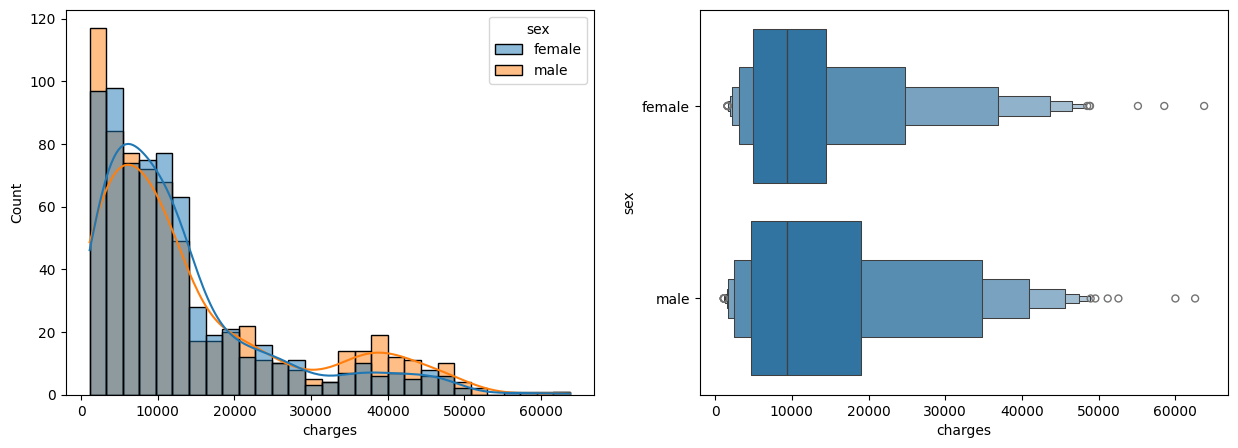

In [10]:
charges_dist_by_cate('sex')

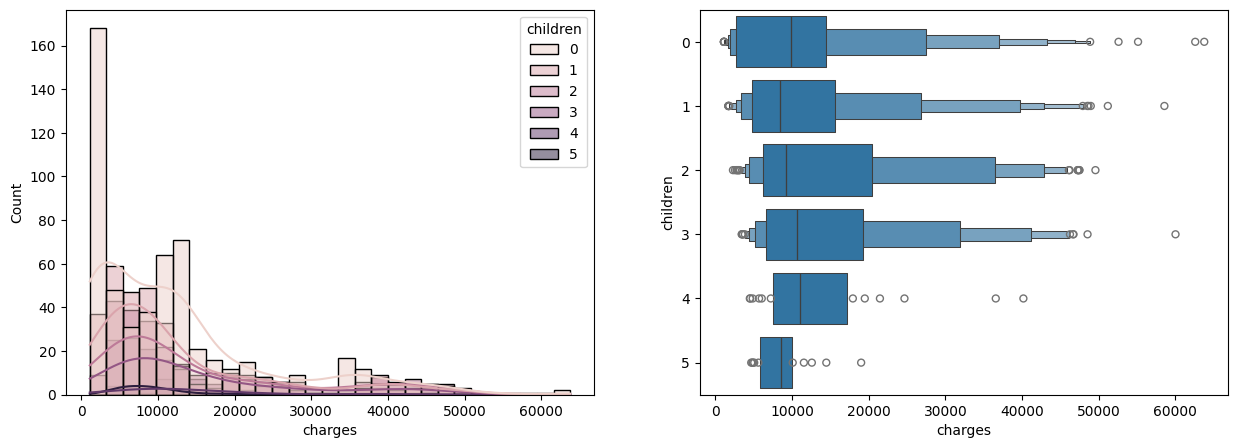

In [11]:
charges_dist_by_cate('children')

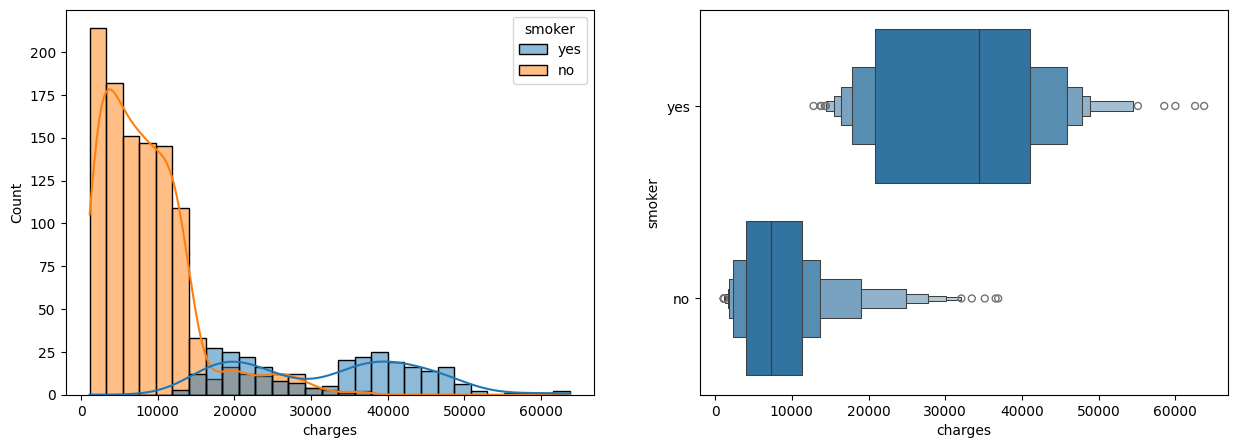

In [12]:
charges_dist_by_cate('smoker')

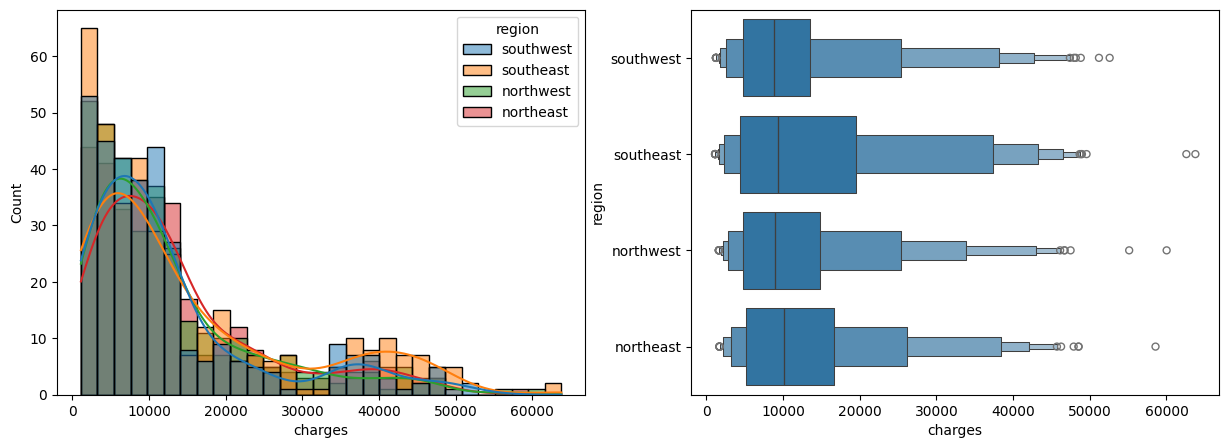

In [13]:
charges_dist_by_cate('region')

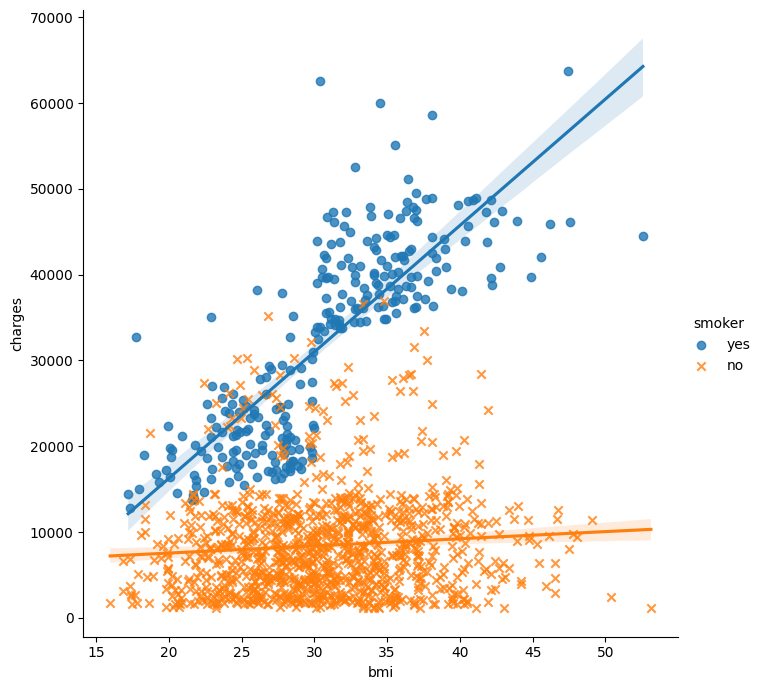

In [14]:
sns.lmplot(data=df, x='bmi', y='charges', hue='smoker', height=7, markers=['o', 'x'])

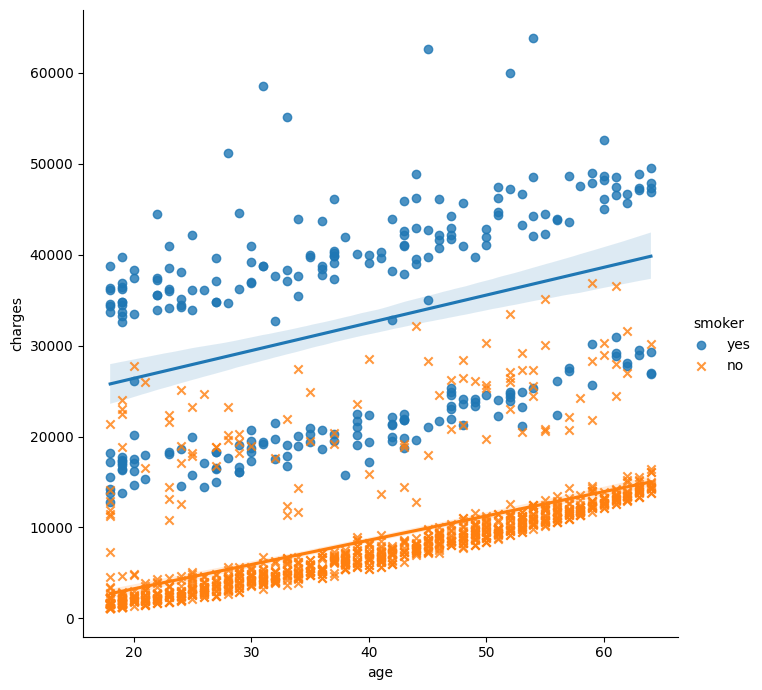

In [15]:
sns.lmplot(data=df, x='age', y='charges', hue='smoker', height=7, markers=['o', 'x'])

In [16]:
df_dummies = pd.get_dummies(df, drop_first=True)

In [17]:
df_dummies.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False


<Axes: >

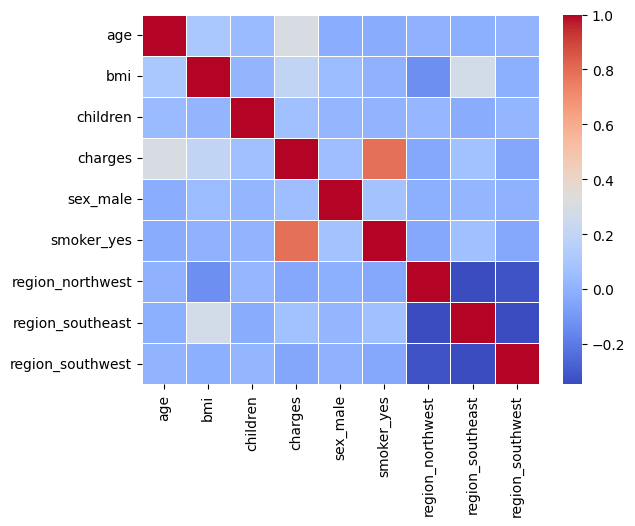

In [18]:
sns.heatmap(df_dummies.corr(),
            cmap='coolwarm',
            annot=False,
            linewidths=0.5)

In [19]:
X = df_dummies.drop('charges', axis=1)
y = df_dummies[['charges']]

In [20]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.15, shuffle=True)

In [21]:
print('Train size: ', x_train.shape)
print('Test size: ', x_test.shape)

Train size:  (1136, 8)
Test size:  (201, 8)


In [22]:
def make_pipeline(model, degree):
    pipeline = Pipeline([
        ('poly', PolynomialFeatures(degree=degree)),
        ('scaler', StandardScaler()),
        ('model', model)
    ])
    return pipeline

In [23]:
def train_and_predict(pipeline, x_train, y_train, x_test):
    pipeline.fit(x_train, y_train)
    y_pred = pipeline.predict(x_test)
    return y_pred.ravel()

In [24]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

def evaluate_model(y_test, y_pred):
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    return round(r2,4), round(mae, 1), round(rmse, 1)

In [25]:
def save_result(result_list, model, degree, r2, mae, rmse):
    model_name = str(model).split('(')[0]
    result_list.append([f'{model_name}, Degree={degree}', r2, mae, rmse])

In [26]:
def plot_result(ax, y_test, y_pred, model_name, degree, r2, mae, rmse):
    y_true = np.array(y_test).ravel()
    y_pred = np.array(y_pred).ravel()
    max_val = max(y_true)
    ax.plot([0, max_val], [0, max_val], color='red', linewidth=3, zorder=1)
    ax.scatter(y_pred, y_true, alpha=0.4, zorder=2)
    ax.set_xlabel("Prediction")
    ax.set_ylabel("Real")
    ax.set_title(f"{model_name} Degree {degree}")
    ax.legend([f"R2: {r2}\nMAE: {mae}\nRMSE: {rmse}"])

In [27]:
list_result = []

def model_prediction(model):
    fig, axs = plt.subplots(1, 2, figsize=(15, 5), sharex=True, sharey=True)
    for i, degree in enumerate([1, 2]):
        pipe = make_pipeline(model, degree)
        y_pred = train_and_predict(pipe, x_train, y_train, x_test)
        r2, mae, rmse = evaluate_model(y_test, y_pred)
        save_result(list_result, model, degree, r2, mae, rmse)

        model_name = str(model).split('(')[0]
        plot_result(axs[i], y_test, y_pred, model_name, degree, r2, mae, rmse)
    plt.show()

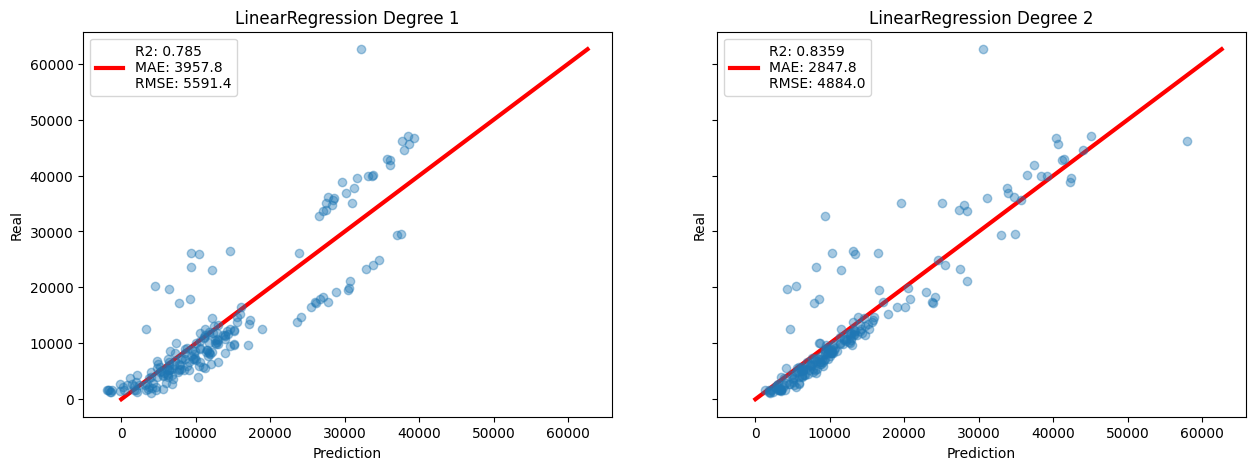

In [28]:
model_prediction(LinearRegression())

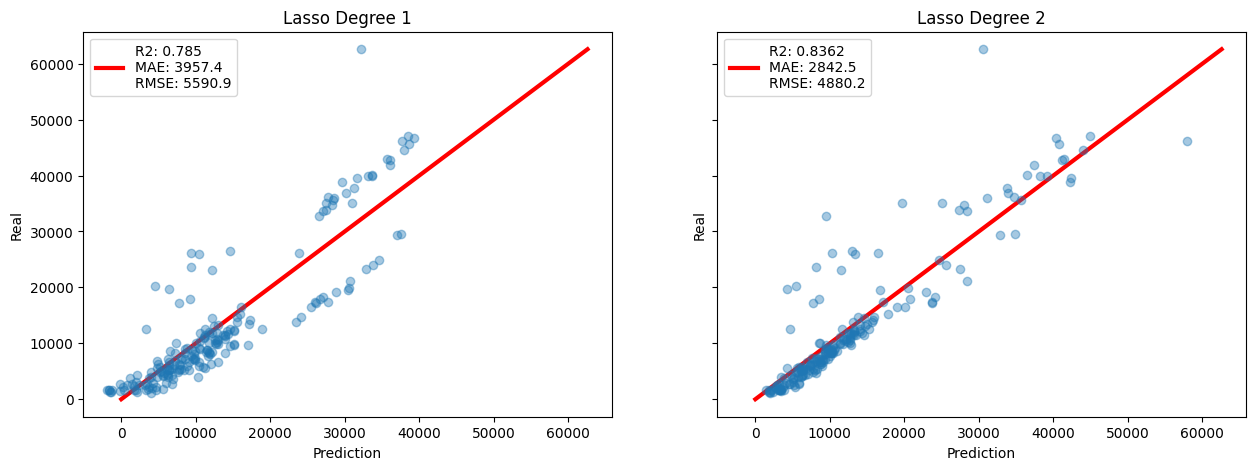

In [29]:
model_prediction(Lasso())

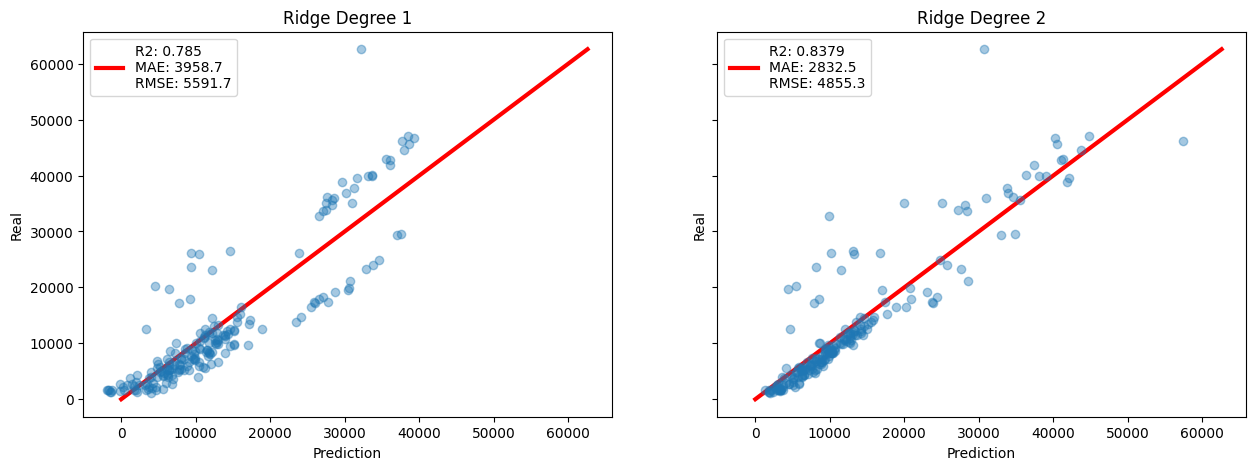

In [30]:
model_prediction(Ridge())

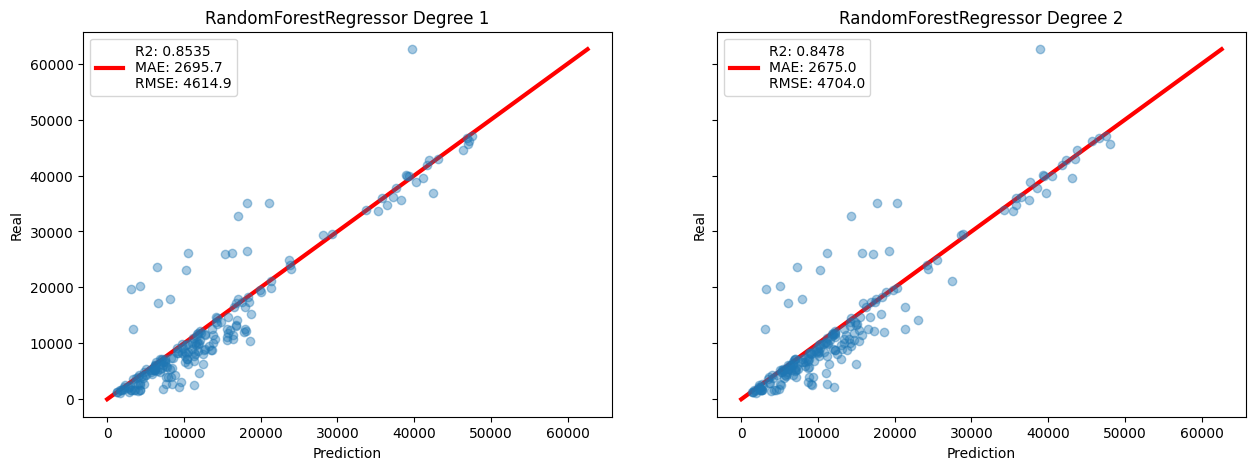

In [31]:
model_prediction(RandomForestRegressor())

In [35]:
list_result[0]

['LinearRegression, Degree=1', 0.785, 3957.8, np.float64(5591.4)]

In [38]:
df_result = pd.DataFrame(list_result , columns=['Model' , 'R2' , 'MAE' , 'RMSE']).sort_values(['MAE' , 'RMSE'] , ignore_index=True).set_index('Model')
df_result

,R2,MAE,RMSE
Model,,,
"RandomForestRegressor, Degree=2",0.8478,2675.0,4704.0
"RandomForestRegressor, Degree=1",0.8535,2695.7,4614.9
"Ridge, Degree=2",0.8379,2832.5,4855.3
"Lasso, Degree=2",0.8362,2842.5,4880.2
"LinearRegression, Degree=2",0.8359,2847.8,4884.0
"Lasso, Degree=1",0.7850,3957.4,5590.9
"LinearRegression, Degree=1",0.7850,3957.8,5591.4
"Ridge, Degree=1",0.7850,3958.7,5591.7
